# Session 8 — Model Evaluation & Improvement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-08-evaluation-tuning.ipynb)

**ML/AI & GenAI Internship** · Holdout · Cross-Validation · Bootstrapping · Overfitting · Grid, Random & Bayesian tuning

---

## How to use this notebook

**Until now you have trusted a single number from a single split.** This session shows that number moves by more than a percentage point for no reason at all — and teaches you how to report a score you can defend.

| # | Topic |
|---|---|
| 1 | Holdout validation, and why one split is not enough |
| 2 | Cross-validation: K-Fold, Stratified, LOOCV |
| 3 | Bootstrapping and confidence intervals |
| 4 | Overfitting and underfitting |
| 5 | Hyperparameter tuning: Grid, Random, Bayesian |

Exercises, MCQs and tasks: [Session 8 guide](../sessions/session-08-evaluation-tuning.md).

In [1]:
import warnings, time; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"

L = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
for c in L.select_dtypes(include="object").columns:
    L[c] = LabelEncoder().fit_transform(L[c])
X, y = L.drop(columns=["loan_status"]), L["loan_status"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
print("ready:", X.shape)

ready: (9997, 13)


---
# 1. Holdout validation, and why one split is not enough

🧠 **Judging a restaurant from one meal.** It could have been an off night, or the chef's best dish. **One visit is evidence; it is not a verdict.**

In [2]:
# The SAME model and the SAME data. Only the random seed changes.
scores = []
for seed in range(10):
    a, b, c, d = train_test_split(X, y, test_size=.2, random_state=seed, stratify=y)
    scores.append(RandomForestClassifier(n_estimators=100, random_state=42).fit(a, c).score(b, d))

scores = np.array(scores)
print("individual scores:", scores.round(4))
print(f"\nmean    {scores.mean():.4f}")
print(f"std     {scores.std():.4f}")
print(f"lowest  {scores.min():.4f}")
print(f"highest {scores.max():.4f}")
print(f"SPREAD  {scores.max() - scores.min():.4f}")
print()
print("Nothing changed except the seed, and the score moved by 1.4 points.")
print("Run seed 0 and you report 0.89. Run another and you report 0.90.")
print("Every 'comparison' on one split with a gap smaller than this is")
print("MEANINGLESS.")

individual scores: [0.8955 0.902  0.8915 0.8955 0.8985 0.8935 0.888  0.8965 0.8925 0.892 ]

mean    0.8945
std     0.0038
lowest  0.8880
highest 0.9020
SPREAD  0.0140

Nothing changed except the seed, and the score moved by 1.4 points.
Run seed 0 and you report 0.89. Run another and you report 0.90.
Every 'comparison' on one split with a gap smaller than this is
MEANINGLESS.


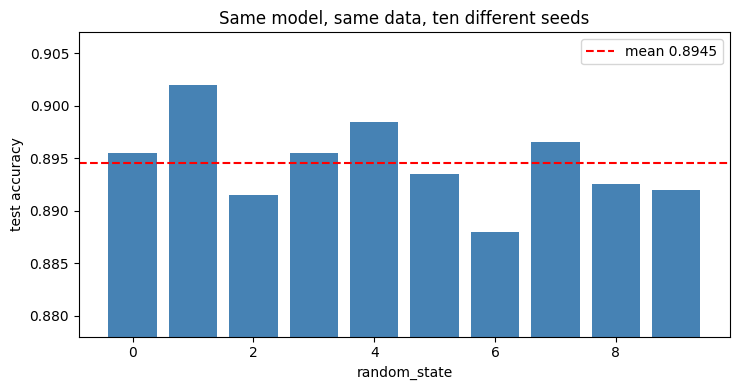

Not defensible:  print(f'Accuracy: {model.score(X_test, y_test):.4f}')
Defensible    :  cv = cross_val_score(model, X, y, cv=5)
                 print(f'{cv.mean():.4f} +/- {cv.std():.4f}')

Use holdout to EXPLORE. Use cross-validation to REPORT.


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(range(10), scores, color="steelblue")
ax.axhline(scores.mean(), color="red", ls="--", label=f"mean {scores.mean():.4f}")
ax.set_ylim(scores.min() - .01, scores.max() + .005)
ax.set_xlabel("random_state"); ax.set_ylabel("test accuracy")
ax.set_title("Same model, same data, ten different seeds")
ax.legend(); plt.tight_layout(); plt.show()

print("Not defensible:  print(f'Accuracy: {model.score(X_test, y_test):.4f}')")
print("Defensible    :  cv = cross_val_score(model, X, y, cv=5)")
print("                 print(f'{cv.mean():.4f} +/- {cv.std():.4f}')")
print()
print("Use holdout to EXPLORE. Use cross-validation to REPORT.")

---
# 2. Cross-validation: K-Fold, Stratified and LOOCV

🧠 **Five judges instead of one.** Each judge sits out one round and scores the round they did not compete in. Everyone gets judged, everyone gets to judge, and you report the average.

```text
fold 1  [TEST ][train][train][train][train]
fold 2  [train][TEST ][train][train][train]
fold 3  [train][train][TEST ][train][train]
fold 4  [train][train][train][TEST ][train]
fold 5  [train][train][train][train][TEST ]
                                            -> mean ± std of 5 scores
```

> `cross_val_score` uses **Stratified** K-Fold automatically for classifiers, so every fold keeps the class balance. You get the right behaviour by default.

In [4]:
from sklearn.model_selection import cross_val_score, LeaveOneOut

cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)
print("individual folds:", cv.round(4))
print(f"reported as     : {cv.mean():.4f} +/- {cv.std():.4f}")
print()
print(f"The folds range from {cv.min():.4f} to {cv.max():.4f}. That range is the")
print("honest picture of how much your score depends on which rows you")
print("happened to test on.")

individual folds: [0.8915 0.8945 0.8804 0.9075 0.8999]
reported as     : 0.8948 +/- 0.0090

The folds range from 0.8804 to 0.9075. That range is the
honest picture of how much your score depends on which rows you
happened to test on.


In [5]:
# Is 10-fold better than 5-fold?
print(f"{'folds':>6}{'mean':>10}{'std':>10}{'seconds':>10}")
print("-" * 36)
for k in [3, 5, 10]:
    t0 = time.time()
    s = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=k)
    print(f"{k:>6}{s.mean():>10.4f}{s.std():>10.4f}{time.time()-t0:>10.1f}")

print("\nThe same answer for over twice the time. More folds is NOT")
print("automatically better - you pay linearly for a marginal gain.")
print("5-fold is the sensible default; 10-fold when data is scarce.")

 folds      mean       std   seconds
------------------------------------


     3    0.8918    0.0067       1.4


     5    0.8948    0.0090       2.7


    10    0.8946    0.0103       5.9

The same answer for over twice the time. More folds is NOT
automatically better - you pay linearly for a marginal gain.
5-fold is the sensible default; 10-fold when data is scarce.


In [6]:
# LOOCV: one fold per row. Only sane on small data.
sub = L.sample(200, random_state=42)
Xs, ys = sub.drop(columns=["loan_status"]), sub["loan_status"]
dt = lambda: DecisionTreeClassifier(max_depth=4, random_state=42)

t0 = time.time(); loo = cross_val_score(dt(), Xs, ys, cv=LeaveOneOut()); t_loo = time.time()-t0
t0 = time.time(); k5 = cross_val_score(dt(), Xs, ys, cv=5); t_k5 = time.time()-t0

print(f"LOOCV   mean {loo.mean():.4f}   {len(loo):>3} fits   {t_loo:.2f}s")
print(f"5-fold  mean {k5.mean():.4f}   {5:>3} fits   {t_k5:.2f}s")
print()
print("LOOCV scores higher because each of its models trains on 199 rows,")
print("while each 5-fold model trains on only 160. With 200 rows that is a")
print("real difference - which is exactly why LOOCV exists.")
print()
print(f"But scale it up: LOOCV on all {len(L):,} rows means {len(L):,} model fits.")
print("At roughly half a second each that is over an hour for ONE number.")
print("\nLOOCV is for when data is so scarce you cannot spare a test set.")

LOOCV   mean 0.8500   200 fits   0.41s
5-fold  mean 0.7900     5 fits   0.01s

LOOCV scores higher because each of its models trains on 199 rows,
while each 5-fold model trains on only 160. With 200 rows that is a
real difference - which is exactly why LOOCV exists.

But scale it up: LOOCV on all 9,997 rows means 9,997 model fits.
At roughly half a second each that is over an hour for ONE number.

LOOCV is for when data is so scarce you cannot spare a test set.


---
# 3. Bootstrapping and confidence intervals

🧠 **An exit poll.** You cannot ask every voter, so you sample, and sample again, and the spread across your samples gives the margin of error. **"52%, ±3 points" is far more honest than "52%".**

The trick is **resampling with replacement**: draw a new test set the same size as the original, allowing duplicates. Score. Repeat 200 times. The middle 95% is your confidence interval.

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xtr, ytr)

rng = np.random.default_rng(0)
boots = []
for _ in range(200):
    idx = rng.integers(0, len(Xte), len(Xte))          # WITH replacement
    boots.append(model.score(Xte.iloc[idx], yte.iloc[idx]))

lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"point estimate  {np.mean(boots):.4f}")
print(f"95% CI          [{lo:.4f}, {hi:.4f}]")
print(f"width           {hi - lo:.4f}")
print()
print(f'Your "{np.mean(boots):.1%} accurate" model is really')
print(f'"somewhere between {lo:.1%} and {hi:.1%}".')

point estimate  0.8949
95% CI          [0.8805, 0.9075]
width           0.0270

Your "89.5% accurate" model is really
"somewhere between 88.0% and 90.8%".


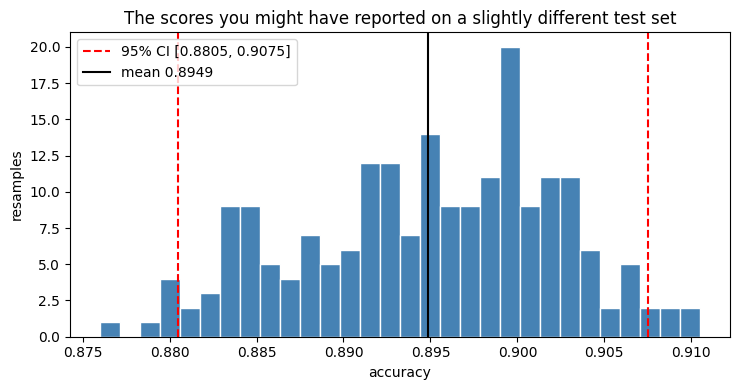

Now recall Session 5: Random Forest 0.8910 vs SVM 0.8780.
That 1.3-point gap sits comfortably inside this 2.7%-wide interval.
The forest is PROBABLY better - and 'probably' is the honest word.
A single split could never have told you that.


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(boots, bins=30, color="steelblue", edgecolor="white")
ax.axvline(lo, color="red", ls="--", lw=1.5, label=f"95% CI [{lo:.4f}, {hi:.4f}]")
ax.axvline(hi, color="red", ls="--", lw=1.5)
ax.axvline(np.mean(boots), color="black", lw=1.5, label=f"mean {np.mean(boots):.4f}")
ax.set_xlabel("accuracy"); ax.set_ylabel("resamples")
ax.set_title("The scores you might have reported on a slightly different test set")
ax.legend(); plt.tight_layout(); plt.show()

print("Now recall Session 5: Random Forest 0.8910 vs SVM 0.8780.")
print(f"That 1.3-point gap sits comfortably inside this {hi-lo:.1%}-wide interval.")
print("The forest is PROBABLY better - and 'probably' is the honest word.")
print("A single split could never have told you that.")

### The three techniques are not competitors

| Technique | Answers |
|---|---|
| **Holdout** | *What did this model score once?* |
| **Cross-validation** | *What does it score on average, and how much does that vary?* |
| **Bootstrapping** | *What range does my true score plausibly lie in?* |

**Cross-validate to choose your model; bootstrap to report its uncertainty.**

---
# 4. Overfitting and underfitting

🧠 **Two students preparing for an exam.**

- **The memoriser** learns every past paper by heart, including the typos. Perfect on those, lost on a new question. **Overfitting.**
- **The skimmer** reads only the chapter titles. Bad on the past papers *and* the new ones. **Underfitting.**
- **The one you want** understood the method: good on both.

> **Watch the gap, not the training score.** A training accuracy of 1.0000 is not an achievement — it is a warning.

In [9]:
depths = [1, 2, 3, 5, 8, 12, 20, None]
tr_s, te_s = [], []
print(f"{'max_depth':<12}{'train':>9}{'test':>9}{'gap':>10}")
print("-" * 40)
for dep in depths:
    t = DecisionTreeClassifier(max_depth=dep, random_state=42).fit(Xtr, ytr)
    tr, te = t.score(Xtr, ytr), t.score(Xte, yte)
    tr_s.append(tr); te_s.append(te)
    print(f"{str(dep):<12}{tr:>9.4f}{te:>9.4f}{tr-te:>+10.4f}")

best = depths[int(np.argmax(te_s))]
print(f"\nTest accuracy PEAKS at depth {best}. That is the model you ship.")
print("Everything left of it underfits; everything right of it overfits.")
print("\nRead the last row: the tree gets EVERY training row right, and is")
print("the WORST model in the table on unseen data. It memorised.")

max_depth       train     test       gap
----------------------------------------
1              0.8286   0.8240   +0.0046
2              0.8286   0.8240   +0.0046
3              0.8327   0.8070   +0.0257
5              0.8803   0.8515   +0.0288
8              0.9007   0.8665   +0.0342
12             0.9416   0.8600   +0.0816
20             0.9961   0.8480   +0.1481


None           1.0000   0.8435   +0.1565

Test accuracy PEAKS at depth 8. That is the model you ship.
Everything left of it underfits; everything right of it overfits.

Read the last row: the tree gets EVERY training row right, and is
the WORST model in the table on unseen data. It memorised.


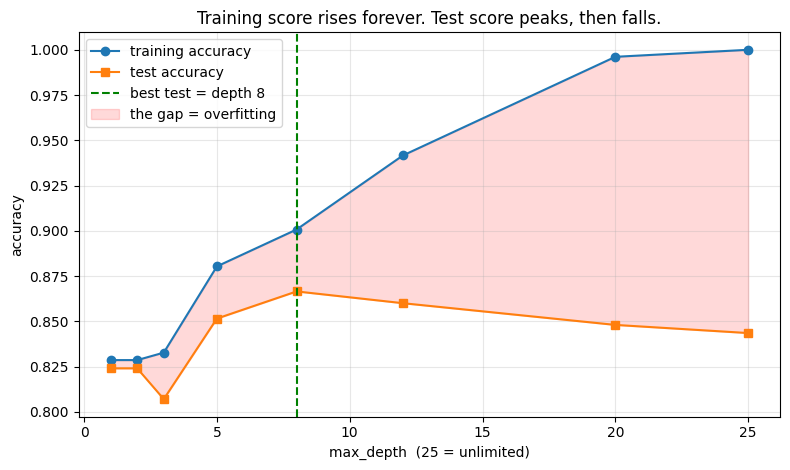

In [10]:
xs = [d if d is not None else 25 for d in depths]
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(xs, tr_s, "o-", label="training accuracy")
ax.plot(xs, te_s, "s-", label="test accuracy")
ax.axvline(best, color="green", ls="--", lw=1.5, label=f"best test = depth {best}")
ax.fill_between(xs, te_s, tr_s, alpha=.15, color="red", label="the gap = overfitting")
ax.set_xlabel("max_depth  (25 = unlimited)"); ax.set_ylabel("accuracy")
ax.set_title("Training score rises forever. Test score peaks, then falls.")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [11]:
# How does a forest reach ~1.0 training accuracy and still generalise?
tree   = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
forest = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr)

print(f"{'':<14}{'train':>9}{'test':>9}{'gap':>10}")
print("-" * 42)
for name, m in [("single tree", tree), ("200 trees", forest)]:
    tr, te = m.score(Xtr, ytr), m.score(Xte, yte)
    print(f"{name:<14}{tr:>9.4f}{te:>9.4f}{tr-te:>+10.4f}")

print("\nBOTH memorise the training set. Only one generalises.")
print("Each tree in the forest overfits a DIFFERENT random slice, and")
print("averaging cancels their individual mistakes - the panel-of-doctors")
print("analogy from Session 5, now with numbers attached.")

                  train     test       gap
------------------------------------------
single tree      1.0000   0.8435   +0.1565
200 trees        1.0000   0.8910   +0.1090

BOTH memorise the training set. Only one generalises.
Each tree in the forest overfits a DIFFERENT random slice, and
averaging cancels their individual mistakes - the panel-of-doctors
analogy from Session 5, now with numbers attached.


---
# 5. Hyperparameter Tuning

**Parameters are learned from data. Hyperparameters are set by you before training.**

🧠 **Tuning a radio.** The station is fixed; the dial is yours. Grid search turns the dial through every marked position. Random search jumps around. Bayesian optimisation **listens to where the signal was getting stronger and tries there next.**

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(random_state=42),
                  {"n_estimators": [50, 100, 200],
                   "max_depth": [5, 10, 20, None],
                   "min_samples_split": [2, 5, 10]},
                  cv=3, n_jobs=-1).fit(Xtr, ytr)
t_grid = time.time() - t0
n_grid = len(gs.cv_results_["params"]) * 3

t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                        {"n_estimators": randint(50, 250),
                         "max_depth": [5, 10, 20, None],
                         "min_samples_split": randint(2, 15)},
                        n_iter=12, cv=3, random_state=42, n_jobs=-1).fit(Xtr, ytr)
t_rand = time.time() - t0

print(f"{'':<16}{'fits':>7}{'seconds':>10}{'best CV':>10}{'test':>9}")
print("-" * 52)
print(f"{'Grid Search':<16}{n_grid:>7}{t_grid:>10.1f}{gs.best_score_:>10.4f}{gs.score(Xte,yte):>9.4f}")
print(f"{'Random Search':<16}{12*3:>7}{t_rand:>10.1f}{rs.best_score_:>10.4f}{rs.score(Xte,yte):>9.4f}")
print()
print("Random Search used a THIRD of the fits and came out slightly ahead.")
print()
print("Why? Grid search wastes most of its budget on hyperparameters that")
print("barely matter - it dutifully tries every min_samples_split at every")
print("depth. Random search draws a DIFFERENT depth every single time, so")
print("at equal budget it explores the dimension that matters far more finely.")

                   fits   seconds   best CV     test
----------------------------------------------------
Grid Search         108      12.4    0.8936   0.8860
Random Search        36       5.0    0.8937   0.8895

Random Search used a THIRD of the fits and came out slightly ahead.

Why? Grid search wastes most of its budget on hyperparameters that
barely matter - it dutifully tries every min_samples_split at every
depth. Random search draws a DIFFERENT depth every single time, so
at equal budget it explores the dimension that matters far more finely.


In [13]:
# The finding nobody puts in a tutorial.
untuned = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)

print(f"untuned default, 5-fold CV : {untuned.mean():.4f} +/- {untuned.std():.4f}")
print(f"Grid Search best, 3-fold   : {gs.best_score_:.4f}")
print(f"Random Search best, 3-fold : {rs.best_score_:.4f}")
print()
print("TUNING DID NOT HELP. All three are inside the +/-%.4f standard" % untuned.std())
print("deviation measured in Topic 2, and inside the bootstrap interval")
print("from Topic 3.")
print()
print("Sometimes the honest answer is 'the defaults were fine'.")
print("Tune when you have a REASON. Never report a gain smaller than noise.")

untuned default, 5-fold CV : 0.8948 +/- 0.0090
Grid Search best, 3-fold   : 0.8936
Random Search best, 3-fold : 0.8937

TUNING DID NOT HELP. All three are inside the +/-0.0090 standard
deviation measured in Topic 2, and inside the bootstrap interval
from Topic 3.

Sometimes the honest answer is 'the defaults were fine'.
Tune when you have a REASON. Never report a gain smaller than noise.


In [14]:
# Bayesian optimisation, built from scratch with sklearn only.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

sub_X = Xtr.sample(3000, random_state=0)
sub_y = ytr.loc[sub_X.index]
DEPTHS = np.arange(2, 26)

def objective(depth):
    return cross_val_score(RandomForestClassifier(n_estimators=60, max_depth=int(depth),
                           random_state=42, n_jobs=-1), sub_X, sub_y, cv=3).mean()

rng = np.random.default_rng(1)
tried = list(rng.choice(DEPTHS, 3, replace=False).astype(float))     # 3 random starts
scores_bo = [objective(t) for t in tried]
print("random starts:", [(int(t), round(s, 4)) for t, s in zip(tried, scores_bo)])

for step in range(7):
    gp = GaussianProcessRegressor(ConstantKernel(1.0) * Matern(length_scale=5.0, nu=2.5),
                                  alpha=1e-4, normalize_y=True,
                                  random_state=0).fit(np.array(tried).reshape(-1, 1), scores_bo)
    mu, sd = gp.predict(DEPTHS.reshape(-1, 1), return_std=True)
    ucb = mu + 1.5 * sd            # predicted score PLUS a bonus for uncertainty
    nxt = next(float(DEPTHS[i]) for i in np.argsort(-ucb) if DEPTHS[i] not in tried)
    s = objective(nxt); tried.append(nxt); scores_bo.append(s)
    print(f"  step {step+1}: try depth {int(nxt):>2} -> {s:.4f}"
          f"   (best so far {max(scores_bo):.4f} at depth {int(tried[int(np.argmax(scores_bo))])})")

best_bo = int(tried[int(np.argmax(scores_bo))])
print(f"\nBayesian:   {len(tried):>2} fits, best depth {best_bo}, cv {max(scores_bo):.4f}")

random starts: [(13, np.float64(0.884)), (12, np.float64(0.8827)), (20, np.float64(0.8847))]


  step 1: try depth  2 -> 0.8747   (best so far 0.8847 at depth 20)


  step 2: try depth 25 -> 0.8853   (best so far 0.8853 at depth 25)


  step 3: try depth 16 -> 0.8780   (best so far 0.8853 at depth 25)


  step 4: try depth 24 -> 0.8853   (best so far 0.8853 at depth 25)


  step 5: try depth 22 -> 0.8857   (best so far 0.8857 at depth 22)


  step 6: try depth  8 -> 0.8877   (best so far 0.8877 at depth 8)


  step 7: try depth 23 -> 0.8853   (best so far 0.8877 at depth 8)

Bayesian:   10 fits, best depth 8, cv 0.8877


Exhaustive: 24 fits, best depth 8, cv 0.8877
Bayesian:   10 fits, best depth 8, cv 0.8877

The SAME optimum for under half the work. With a 12-hour training
run, that difference is days.


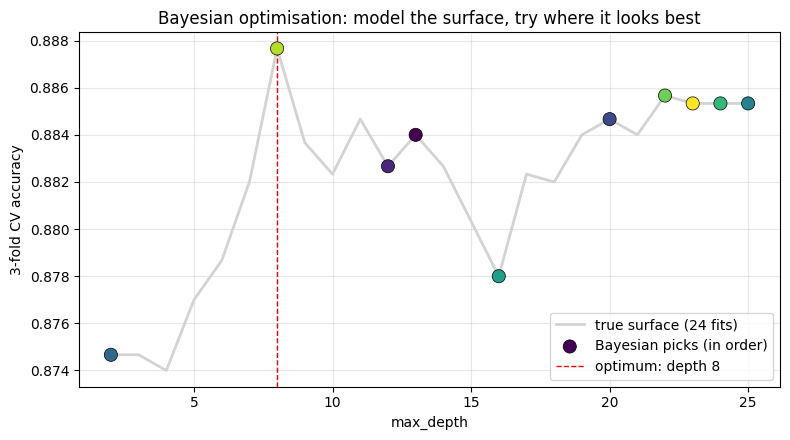


'mu + 1.5*sd' is the whole idea: score each untried value by how
good we PREDICT it is, plus how UNCERTAIN we are about it. That
balance has a name: exploitation versus exploration.

In production: pip install optuna. But the idea is what you just read.


In [15]:
# How does that compare with just trying everything?
all_scores = [objective(dd) for dd in DEPTHS]
best_ex = int(DEPTHS[int(np.argmax(all_scores))])
print(f"Exhaustive: {len(DEPTHS)} fits, best depth {best_ex}, cv {max(all_scores):.4f}")
print(f"Bayesian:   {len(tried)} fits, best depth {best_bo}, cv {max(scores_bo):.4f}")
print()
print("The SAME optimum for under half the work. With a 12-hour training")
print("run, that difference is days.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(DEPTHS, all_scores, "-", color="lightgrey", lw=2, label="true surface (24 fits)")
ax.scatter(tried, scores_bo, c=range(len(tried)), cmap="viridis", s=90,
           zorder=3, edgecolor="k", linewidth=.5, label="Bayesian picks (in order)")
ax.axvline(best_ex, color="red", ls="--", lw=1, label=f"optimum: depth {best_ex}")
ax.set_xlabel("max_depth"); ax.set_ylabel("3-fold CV accuracy")
ax.set_title("Bayesian optimisation: model the surface, try where it looks best")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\n'mu + 1.5*sd' is the whole idea: score each untried value by how")
print("good we PREDICT it is, plus how UNCERTAIN we are about it. That")
print("balance has a name: exploitation versus exploration.")
print("\nIn production: pip install optuna. But the idea is what you just read.")

---
# ✅ Before you move on

- [ ] Showing that a single split moves by over a percentage point on seed alone
- [ ] Reporting **mean ± std**, never a lone number
- [ ] Knowing why `cross_val_score` stratifies for classifiers
- [ ] Knowing when LOOCV is worth it and when it is a waste
- [ ] Putting a bootstrap confidence interval on a score
- [ ] Diagnosing overfitting from the **gap**, not the training score
- [ ] Knowing a training accuracy of 1.0 is a warning, not an achievement
- [ ] Running Grid, Random and Bayesian search, and why Random usually wins
- [ ] **Never reporting a gain smaller than your noise**

**Exercises, MCQs and tasks:** [Session 8 guide](../sessions/session-08-evaluation-tuning.md)

| | |
|---|---|
| **Previous** | [Session 7 — Unsupervised Learning](../sessions/session-07-unsupervised.md) |
| **Next** | [Sessions index](../sessions/README.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |